<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-DeepLearning/blob/main/DeepLearning/ex02_%EC%9C%A0%EB%B0%A9%EC%95%94_%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%85%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 목표
- 유방암 데이터셋(이진 분류)
  - 환자의 종양 특성 정보 -> 해당 종양이 악성, 양성인지를 분류하는 모델

### 실습의 핵심
- 예측 결과 값의 유형에 따라 변하는 설정값들이 존재
- 활성화 함수(activation function)가 어떤 역할을 하는지

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

In [ ]:
# 데이터 로드 및 변수 저장
breast_cancer = load_breast_cancer()

In [ ]:
type(breast_cancer)
# Bunch : 머신러닝 데이터셋에서만 사용하는 머신러닝 전용 데이터 구조
# 딕셔너리와 비슷하게 구성돼서 key값으로 접근하면 됨

sklearn.utils._bunch.Bunch

In [ ]:
breast_cancer.keys()
# data : 문제(X) 데이터
# target : 정답(y) 데이터
# feature_names : 문제 데이터 컬럼명
# DESCR : 데이터 설명

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
print(breast_cancer["DESCR"])
# 종양의 생김새와 특징을 숫자로 정량화한 데이터

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [ ]:
# 문제, 정답 데이터 분리해서 저장
X = breast_cancer["data"]
y = breast_cancer["target"]

X.shape, y.shape

((569, 30), (569,))

In [ ]:
# 정답데이터 class 이름 확인
# breast_cancer["target_names"]
breast_cancer.target_names
# 'malignant': 악성
# 'benign' : 양성

array(['malignant', 'benign'], dtype='<U9')

In [ ]:
# 1. 분리 전 y 데이터 구성 비율
# 악성 : 양성
np.unique(y)
print("malignant(악성) :", (y == 0).sum() / len(y))
print("benign(양성) :", (y == 1).sum() / len(y))

malignant(악성) : 0.37258347978910367
benign(양성) : 0.6274165202108963


In [ ]:
# 2. train, test 분리
# test 사이즈 0.3, random_state = 10
# 정답의 비율을 유지하면서 분리하는 파라미터 전달
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=10,
    stratify=y
)

In [ ]:
# 3. y_train, y_test 구성 비율이 분리 전과 비슷한지 확인
print("malignant(악성) :", (y_train == 0).sum() / len(y_train))
print("benign(양성) :", (y_train == 1).sum() / len(y_train))
print("malignant(악성) :", (y_test == 0).sum() / len(y_test))
print("benign(양성) :", (y_test == 1).sum() / len(y_test))

malignant(악성) : 0.37185929648241206
benign(양성) : 0.628140703517588
malignant(악성) : 0.3742690058479532
benign(양성) : 0.6257309941520468


딥러닝 모델링 - 이진 분류

### 퍼셉트론 vs 다층 퍼셉트론(MLP)
- 입력과 출력으로만 이루어진 단층 퍼셉트론에서 차원의 수(layer의 개수)를 확장해서 보다 복잡한 문제(비선형)를 해결할 수 있는 신경망 -> 다층 퍼셉트론

- 비선형 문제를 해결할 수 있는 핵심 -> `activation function(활성화 함수)`

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer

In [ ]:
# 1. 신경망 구조 설계
# 1) 뼈대 생성
model = Sequential()

# 2) 입력층 : 문제 데이터 1개를 받아줄 수 있는 상태로 모양을 잡아줌
model.add(InputLayer(shape=(30, )))
# X[0].shape 동일하게 shape 설정
# Dense : 입력값 또는 이전 층에서 받은 값을 모두 계산에 사용

# 3) 중간층(은닉층) : 복잡한 연산을 담당
model.add(Dense(units=32, activation="sigmoid"))
model.add(Dense(units=64, activation="sigmoid"))
model.add(Dense(units=128, activation="sigmoid"))
model.add(Dense(units=256, activation="sigmoid"))
model.add(Dense(units=128, activation="sigmoid"))
model.add(Dense(units=64, activation="sigmoid"))
model.add(Dense(units=32, activation="sigmoid"))
# 활성화 함수 역할 1) 중간층에서 다음 노드로 값을 넘길지 말지 결정하는 스위치(역치 개념)
#                  2) 비선형 변환

# 4) 출력층 : 출력 모양을 잡아주는 역할
# -> 정답 데이터의 종류(수치, 이진분류, 다중분류)에 따라 형태가 변화
model.add(Dense(units=1, activation="sigmoid"))
#                  3) 출력 형식에 맞게 예측값을 변화
# sigmoid : 해당 클래스에 속할 확률 계산

# activation의 기본값 linear -> 회귀 모델 출력층에서 사용(중간층에서 계산한 결과 그대로 출력)

In [ ]:
# 2. 학습 방법 설정
model.compile(
    loss="binary_crossentropy", # 분류 모델은 mse로 오차 측정하면 크기가 너무 작음
                                # 학습을 제대로 할 수 없음 -> crossentropy 사용, binary(이진)
    optimizer="SGD",
    metrics=["accuracy"]
)

In [ ]:
# 3. 학습
h = model.fit(
    X_train, y_train,
    validation_split=0.3,
    epochs=100
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6223 - loss: 0.6796 - val_accuracy: 0.6417 - val_loss: 0.6716
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6732 - val_accuracy: 0.6417 - val_loss: 0.6648
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6687 - val_accuracy: 0.6417 - val_loss: 0.6611
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6664 - val_accuracy: 0.6417 - val_loss: 0.6586
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6652 - val_accuracy: 0.6417 - val_loss: 0.6569
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6645 - val_accuracy: 0.6417 - val_loss: 0.6559
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6223 - loss: 0.6640 - val_accuracy: 0.6417 - val_loss: 0.6552
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6635 - val_accuracy: 0.6417 - val_loss:

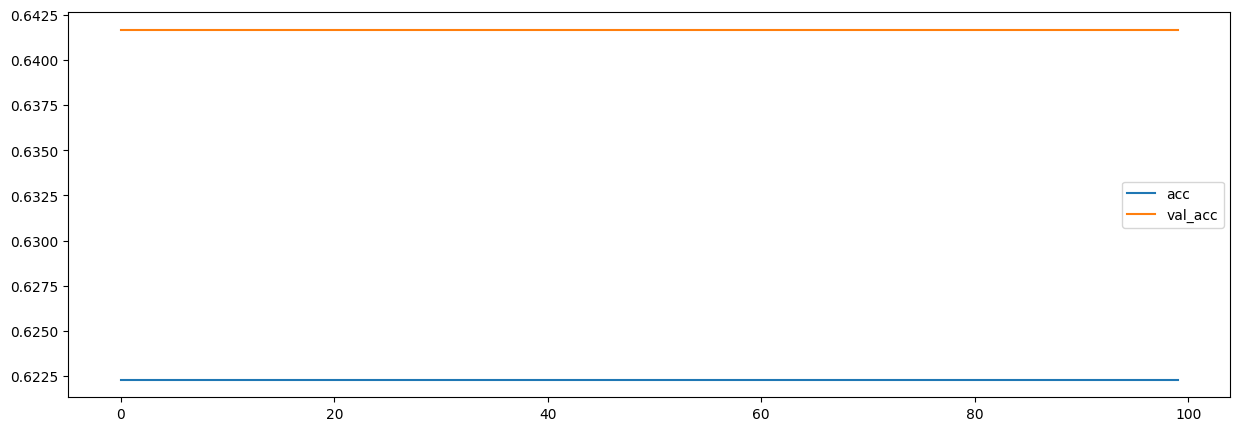

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(h.history["accuracy"], label="acc")
plt.plot(h.history["val_accuracy"], label="val_acc")
plt.legend()
plt.show()

# optimizer가 실제 최적의 값을 찾지 못하고 가짜 최적의 값(local minima)을 찾은 상태로 멈춰버림

![image](https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Extrema_example_original.svg/1280px-Extrema_example_original.svg.png)

In [ ]:
# 2. 학습 방법 설정
model.compile(
    loss="binary_crossentropy", # 분류 모델은 mse로 오차 측정하면 크기가 너무 작음
                                # 학습을 제대로 할 수 없음 -> crossentropy 사용, binary(이진)
    optimizer="Adam",
    metrics=["accuracy"]
)

In [ ]:
# 3. 학습
h = model.fit(
    X_train, y_train,
    validation_split=0.3,
    epochs=100
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6223 - loss: 0.6668 - val_accuracy: 0.6417 - val_loss: 0.6552
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6660 - val_accuracy: 0.6417 - val_loss: 0.6554
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6682 - val_accuracy: 0.6417 - val_loss: 0.6531
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6704 - val_accuracy: 0.6417 - val_loss: 0.6564
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6631 - val_accuracy: 0.6417 - val_loss: 0.6526
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6639 - val_accuracy: 0.6417 - val_loss: 0.6520
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6223 - loss: 0.6634 - val_accuracy: 0.6417 - val_loss: 0.6530
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6223 - loss: 0.6622 - val_accuracy: 0.6417 - val_loss:

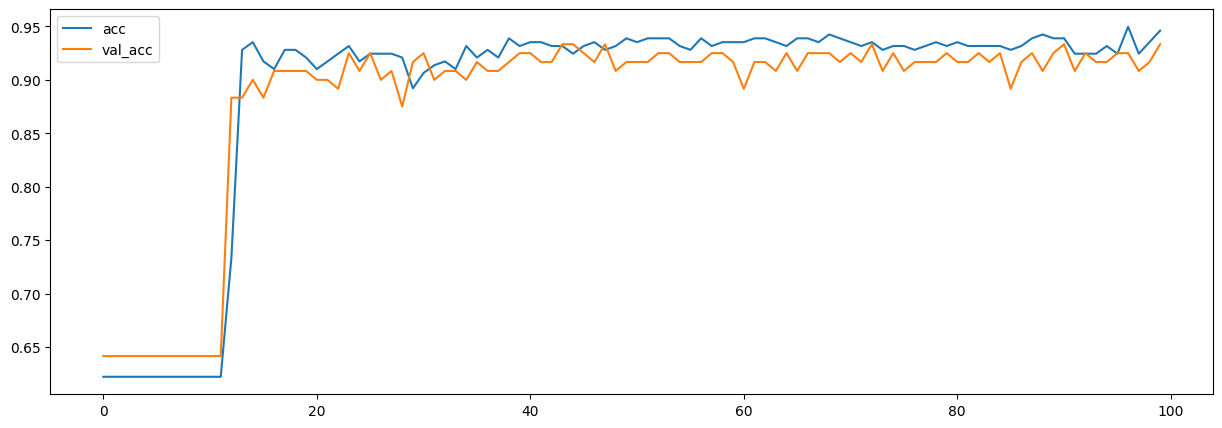

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(h.history["accuracy"], label="acc")
plt.plot(h.history["val_accuracy"], label="val_acc")
plt.legend()
plt.show()

### 1. 경사하강법(Gradient Descent)의 원리
경사하강법은 모델의 **비용 함수(Loss Function)를 최소화**하기 위해 가중치(Parameter)를 반복적으로 업데이트하는 최적화 알고리즘입니다.
- **핵심 아이디어**: 함수의 기울기(Gradient)를 구하고, 그 기울기의 반대 방향으로 가중치를 이동시켜 오차가 가장 작은 지점을 찾아갑니다.
- **학습률(Learning Rate)**: 가중치를 한 번에 얼마나 이동시킬지 결정하는 상수입니다. 너무 크면 최적점을 지나칠 수 있고, 너무 작으면 학습 속도가 매우 느려집니다.

### 2. 학습 데이터 양에 따른 종류

| 종류 | 특징 | 장점 | 단점 |
| :--- | :--- | :--- | :--- |
| **BGD (Batch)** | 전체 데이터를 사용하여 기울기 계산 | 학습 과정이 안정적이고 부드러움 | 계산량이 많아 속도가 느리고 메모리 부담이 큼 |
| **SGD (Stochastic)** | 데이터 1개마다 기울기를 계산하여 업데이트 | 속도가 매우 빠르고 Local Minima 탈출에 유리 | 결과의 변동성이 크고 최적값 주위에서 산만하게 움직임 |
| **Mini-batch GD** | 데이터를 일정 크기(Batch Size)로 나누어 학습 | GPU 가속 활용 가능, BGD와 SGD의 절충안 | 배치 크기라는 추가적인 하이퍼파라미터 설정 필요 |

### 3. 주요 최적화 알고리즘 (Optimizers)
- **SGD**: 가장 기본적인 경사하강법
- **Momentum**: 과거 이동 방향과 속도를 유지하려는 성질(관성)을 추가하여 가속도를 붙임
- **Adagrad / RMSProp**: 변수별로 학습률을 다르게 조절 (자주 등장하는 변수는 작게, 드문 변수는 크게)
- **Adam**: Momentum과 RMSProp의 장점을 합친 알고리즘으로, 대부분의 딥러닝 모델에서 기본적으로 사용됨

### 최적화 함수(Optimizer)
- 모델 오차(loss)를 최소화하기 위해서 w,b를 업데이트하는 알고리즘
- 모델이 얼마나 틀렸는지를 보고 학습하는 방향을 정하는 역할
- 경사하강법을 기반으로 작동

| Optimizer | 특징 | 비유 |
|------------|------|------|
| **SGD** | 단순한 경사하강법, 한 걸음씩 내려감 | 눈가린 사람이 한 걸음씩 내려가기 |
| **Momentum** | 이전 이동 방향(관성)을 고려 | 공이 구르듯 빠르게 이동 |
| **RMSProp** | 최근 기울기의 변화에 따라 학습률 조절 | 경사 심하면 천천히, 완만하면 빠르게 |
| **Adam** | Momentum + RMSProp 결합, 가장 많이 사용 | 똑똑한 하이브리드 드라이버 🚗 |


In [ ]:
# 활성화 함수 변경
model2 = Sequential()

model2.add(InputLayer(shape=X[0].shape))

model2.add(Dense(32, activation="relu"))
model2.add(Dense(64, activation="relu"))
model2.add(Dense(128, activation="relu"))
model2.add(Dense(256, activation="relu"))
model2.add(Dense(128, activation="relu"))
model2.add(Dense(64, activation="relu"))
model2.add(Dense(32, activation="relu"))

model2.add(Dense(1, activation="sigmoid"))

In [ ]:
model2.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [ ]:
h2 = model2.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 100
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4340 - loss: 7.5944 - val_accuracy: 0.3250 - val_loss: 4.6374
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6226 - loss: 1.4353 - val_accuracy: 0.7000 - val_loss: 0.8379
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7421 - loss: 0.5478 - val_accuracy: 0.7250 - val_loss: 0.5524
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7767 - loss: 0.4631 - val_accuracy: 0.7250 - val_loss: 0.6195
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8805 - loss: 0.3187 - val_accuracy: 0.8875 - val_loss: 0.3031
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8836 - loss: 0.2859 - val_accuracy: 0.9125 - val_loss: 0.2114
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8962 - loss: 0.2569 - val_accuracy: 0.9250 - val_loss: 0.2280
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8962 - loss: 0.2962 - val_accuracy: 0.9125 -

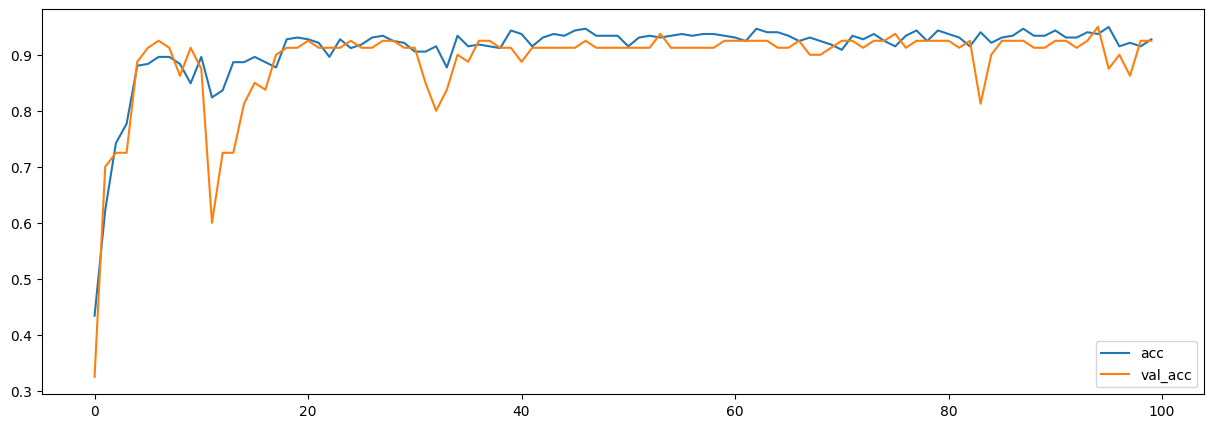

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(h2.history["accuracy"], label="acc")
plt.plot(h2.history["val_accuracy"], label="val_acc")
plt.legend()
plt.show()

# sigmoid 함수를 중간층의 활성화 함수로 사용했을 때 7개의 층을 거치면서 입력값이 점점 작아지는 상황 발생
# -> 경사 소실(vanishing gradient)
# relu 함수가 경사소실 문제를 해결한 대표적인 활성화 함수
# sigmoid에 비해 더 빨리 최적의 w, b 값을 찾아갈 수 있음

### 활성화 함수(Activation Function)의 역할과 종류

#### 1. 활성화 함수의 역할
*   **비선형성(Non-linearity) 부여**: 인공 신경망의 은닉층에 활성화 함수가 없다면, 층을 아무리 깊게 쌓아도 결국은 단순한 선형 회귀 모델과 같아집니다. 활성화 함수는 네트워크에 비선형성을 추가하여 복잡한 패턴을 학습할 수 있게 해줍니다.
*   **신호 전달 여부 결정**: 이전 층에서 계산된 값(가중치 합)을 다음 층으로 전달할지, 전달한다면 얼만큼의 크기로 전달할지를 결정하는 스위치 역할을 합니다.

---

#### 2. 대표적인 활성화 함수 종류

| 함수 이름 | 수식/형태 | 출력 범위 | 특징 및 용도 | 단점 |
| :--- | :--- | :--- | :--- | :--- |
| **Sigmoid (시그모이드)** | $1 / (1 + e^{-x})$ | 0 ~ 1 | - 0과 1 사이의 부드러운 곡선<br>- **출력층**: 이진 분류 모델의 확률값 출력 시 사용 | - **경사 소실(Vanishing Gradient)** 발생<br>- 연산 비용이 높음 |
| **Tanh (하이퍼볼릭 탄젠트)** | $(e^x - e^{-x}) / (e^x + e^{-x})$ | -1 ~ 1 | - 중심이 0으로 맞춰져 있어 Sigmoid보다 학습 효율이 좋음<br>- 주로 RNN 등에서 사용됨 | - 여전히 양끝에서 경사 소실 문제 발생 |
| **ReLU (렐루)** | $max(0, x)$ | 0 ~ $\infty$ | - 양수는 그대로, 음수는 0으로 반환<br>- **은닉층의 표준**: 경사 소실 문제를 해결하고 연산 속도가 매우 빠름 | - **Dying ReLU**: 입력이 음수면 기울기가 0이 되어 노드가 죽어버리는 현상 발생 |
| **Leaky ReLU** | $max(\alpha x, x)$<br>(보통 $\alpha=0.01$) | $-\infty$ ~ $\infty$ | - 음수 입력에 대해 아주 작은 기울기($\alpha$)를 주어 Dying ReLU 문제를 해결 | - $\alpha$값을 하이퍼파라미터로 설정해야 함 |
| **Softmax (소프트맥스)** | $\frac{e^{x_i}}{\sum e^{x_j}}$ | 0 ~ 1<br>(총합 1) | - 여러 클래스에 대한 확률값을 출력<br>- **출력층**: 다중 클래스 분류 모델에 사용됨 | - 은닉층에서는 사용하지 않음 |

> **요약**: 일반적으로 **은닉층에는 ReLU**를 사용하고, **출력층에는 해결하려는 문제에 따라** 선형 함수(회귀), Sigmoid(이진 분류), Softmax(다중 분류)를 선택하여 사용합니다.

### sigmoid
![image](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fbazywr%2FbtrzJ3oDBs1%2FAAAAAAAAAAAAAAAAAAAAAGbxnpcUeEILcb965TAiBDEtcEL5UzhXeBH7GYHIcZRV%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1777561199%26allow_ip%3D%26allow_referer%3D%26signature%3DF%252B5%252BQKuGdMdiupaEYJekhaDQ40k%253D)

### Relu
![image](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FvgJna%2FbtqQzRGmwcO%2FAAAAAAAAAAAAAAAAAAAAAF2TqoGwCrvDWO4WUKsa9LPeybwgzWbow476RGHGR8n8%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1777561199%26allow_ip%3D%26allow_referer%3D%26signature%3DNAuS41w8W9Au9KK95qxwQ1IT2Gk%253D)
